# Power Quality Disturbance Detection

This notebook demonstrates the system detecting, identifying, and labelling abnormal patterns in electrical signals.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_xpqrs, get_time_axis_ms, XPQRS_CLASSES
from predictor import predict_signal, predict_batch

sns.set_theme(style='whitegrid')
%matplotlib inline

TUNED_MODEL_PATH = '../results/models/xpqrs_random_forest_tuned.pkl'
BASE_MODEL_PATH = '../results/models/xpqrs_random_forest.pkl'
DEMO_MODEL_PATH = TUNED_MODEL_PATH if os.path.exists(TUNED_MODEL_PATH) else BASE_MODEL_PATH

# Load dataset
signals, labels = load_xpqrs('../dataset/XPQRS/')
time_ms = get_time_axis_ms()
print(f'Loaded {len(signals)} signals across {len(np.unique(labels))} classes')
print(f'Using model: {DEMO_MODEL_PATH}')

Loaded 17000 signals across 17 classes
Using model: ../results/models/xpqrs_random_forest_tuned.pkl


---
## 1. Single Signal Prediction

Pick any signal, plot it, and predict what it is.

In [2]:
def demo_predict(signal, true_label=None, model_path=DEMO_MODEL_PATH):
    """Plot a signal and show the prediction result."""
    result = predict_signal(signal, model_path=model_path)

    is_normal = result['status'] == 'Normal'
    color = '#2e7d32' if is_normal else '#c62828'
    bg_color = '#e8f5e9' if is_normal else '#ffebee'

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5),
                             gridspec_kw={'width_ratios': [2, 1]})

    # Left: Waveform
    ax = axes[0]
    ax.plot(time_ms, signal, color=color, linewidth=1.5)
    ax.fill_between(time_ms, signal, alpha=0.1, color=color)
    ax.set_xlabel('Time (ms)', fontsize=11)
    ax.set_ylabel('Amplitude', fontsize=11)
    ax.set_title('Input Signal', fontsize=13, fontweight='bold')
    ax.set_xlim(0, 20)
    ax.grid(True, alpha=0.3)

    # Right: Prediction result
    ax2 = axes[1]
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 10)
    ax2.set_facecolor(bg_color)
    ax2.set_xticks([])
    ax2.set_yticks([])

    ax2.text(5, 9, 'PREDICTION', ha='center', fontsize=14, fontweight='bold', color='#333')
    ax2.text(5, 7.3, result['status'], ha='center', fontsize=26, fontweight='bold', color=color)
    ax2.text(5, 5.5, result['disturbance_type'].replace('_', ' '), ha='center', fontsize=14, fontweight='bold', color='#333')
    ax2.text(5, 4.0, f"Confidence: {result['confidence']:.0%}", ha='center', fontsize=13, color='#555')

    if true_label:
        match = true_label == result['disturbance_type']
        ax2.text(5, 2.2, f"True label: {true_label.replace('_', ' ')}", ha='center', fontsize=10, color='#777')
        mark = 'Correct' if match else 'Incorrect'
        mark_color = '#2e7d32' if match else '#c62828'
        ax2.text(5, 1.0, mark, ha='center', fontsize=12, fontweight='bold', color=mark_color)

    plt.tight_layout()
    plt.show()

    return result

### Normal Signal

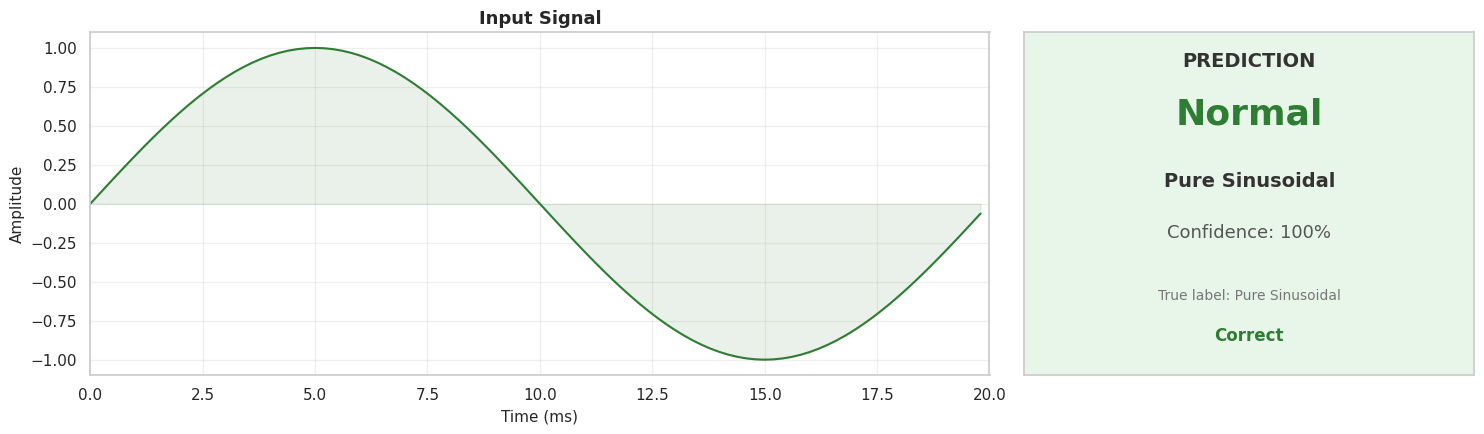

In [3]:
idx = (labels == 'Pure_Sinusoidal').nonzero()[0][42]
_ = demo_predict(signals[idx], 'Pure_Sinusoidal')

### Voltage Sag (voltage drops)

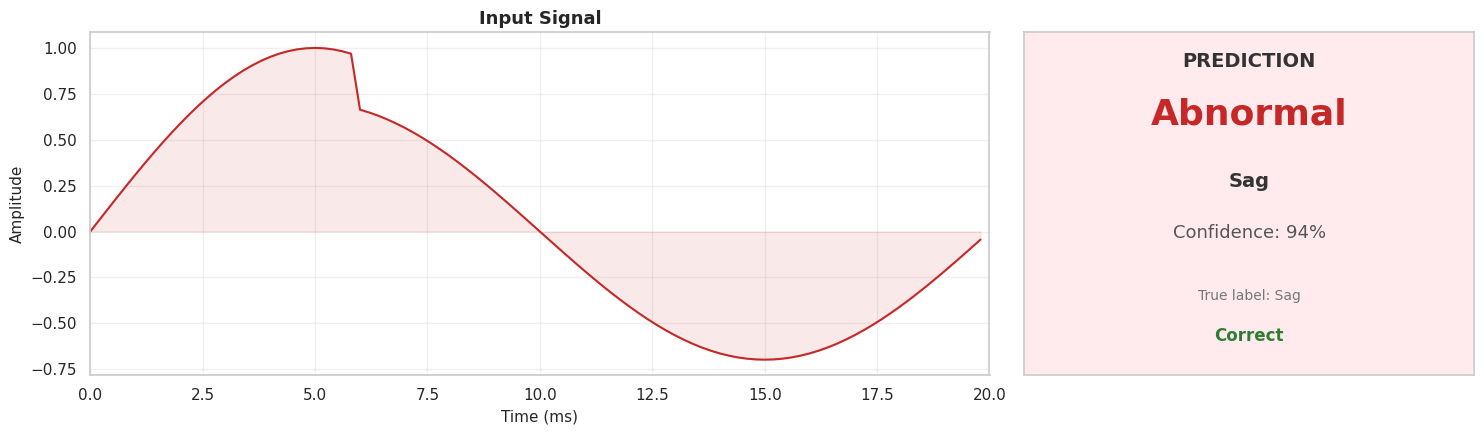

In [4]:
idx = (labels == 'Sag').nonzero()[0][10]
_ = demo_predict(signals[idx], 'Sag')

### Harmonics (waveform distortion)

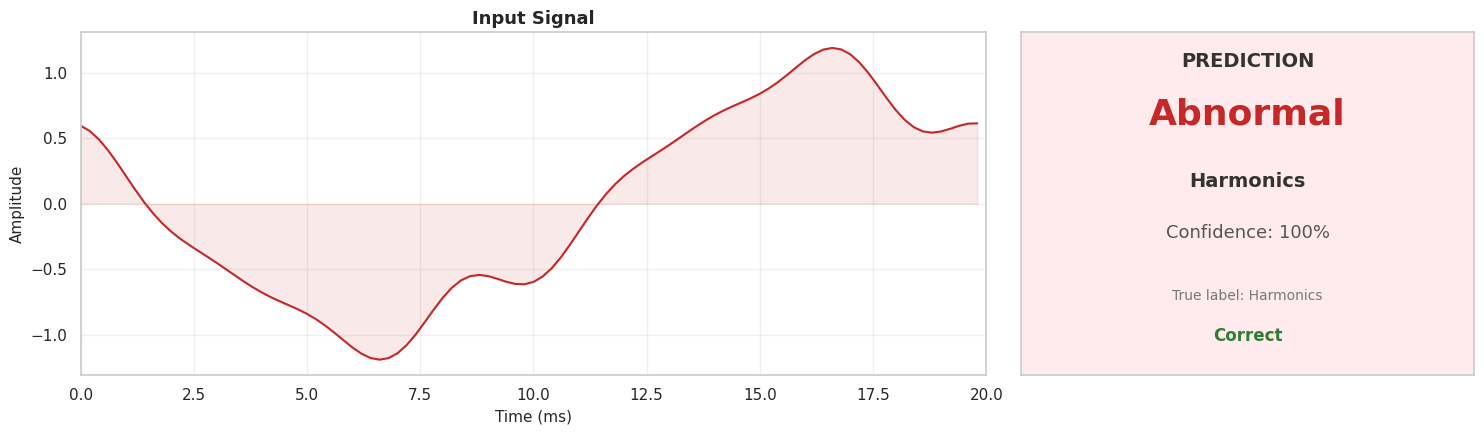

In [5]:
idx = (labels == 'Harmonics').nonzero()[0][5]
_ = demo_predict(signals[idx], 'Harmonics')

### Interruption (power loss)

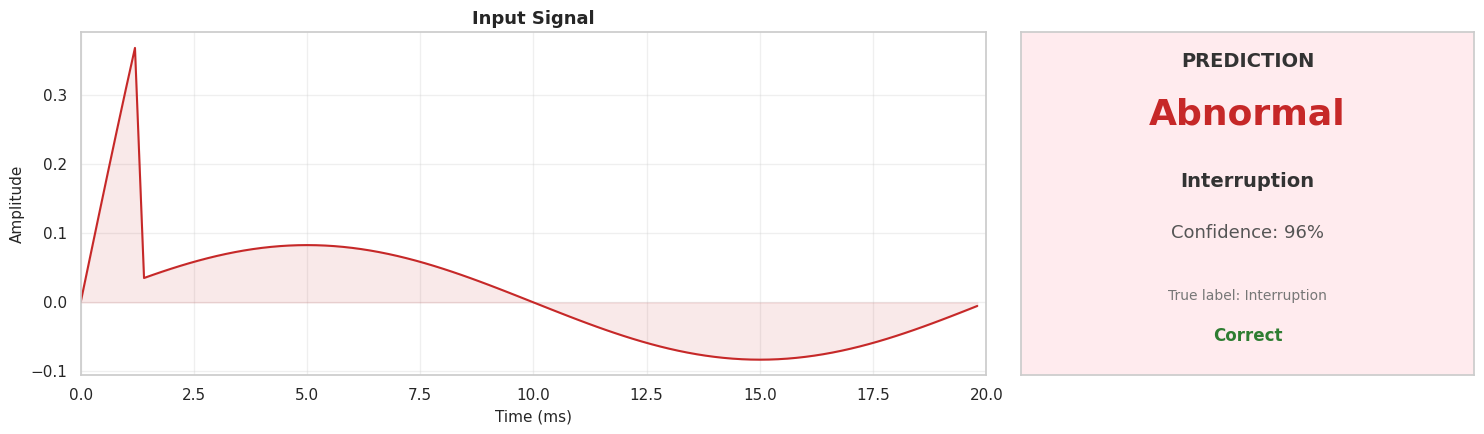

In [6]:
idx = (labels == 'Interruption').nonzero()[0][20]
_ = demo_predict(signals[idx], 'Interruption')

### Transient (sharp spike)

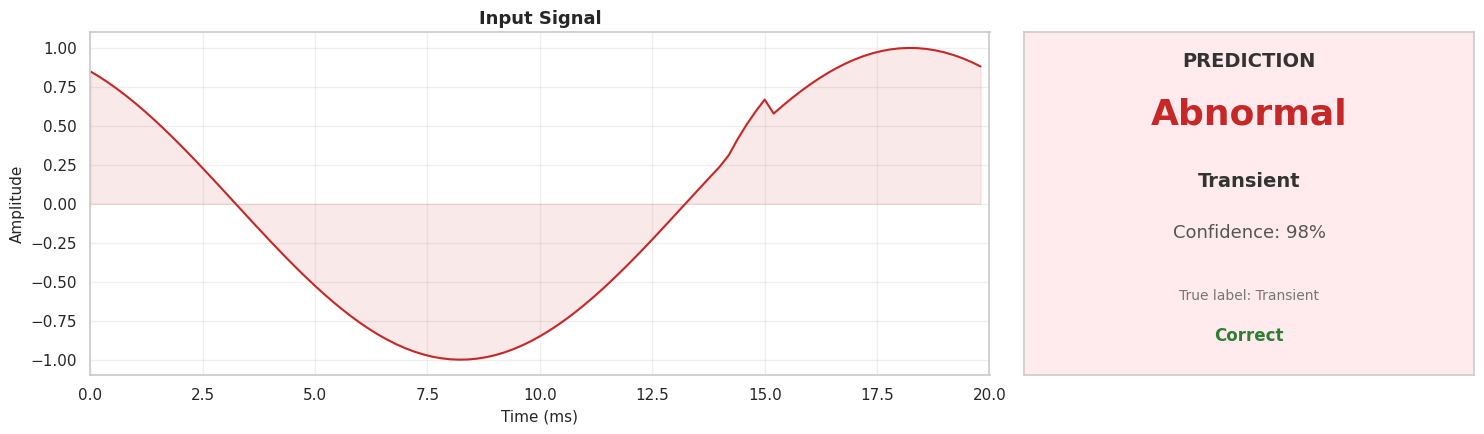

In [7]:
idx = (labels == 'Transient').nonzero()[0][15]
_ = demo_predict(signals[idx], 'Transient')

### Flicker (voltage fluctuation)

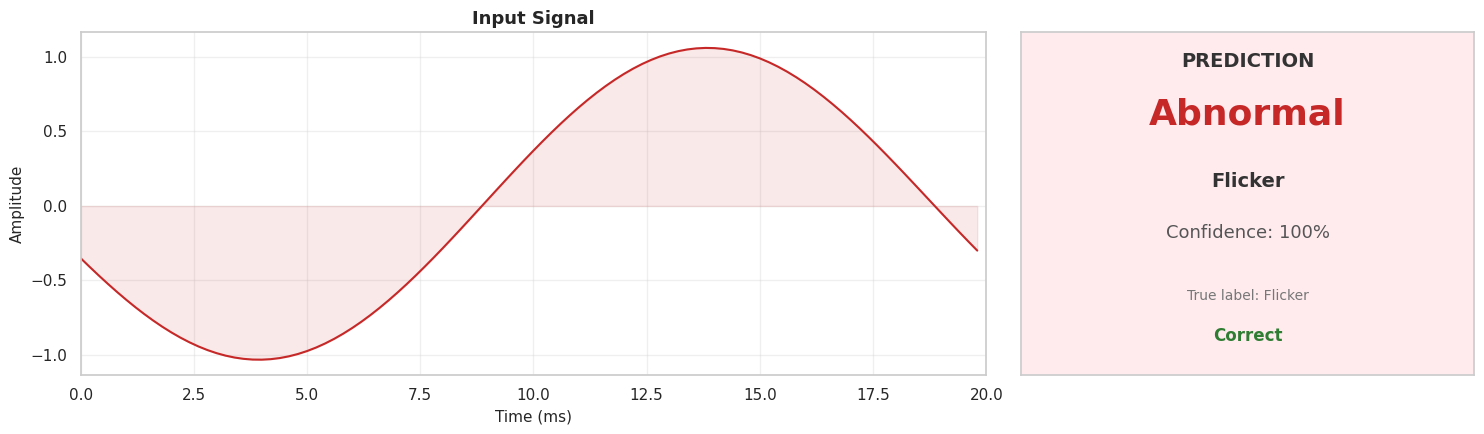

In [8]:
idx = (labels == 'Flicker').nonzero()[0][8]
_ = demo_predict(signals[idx], 'Flicker')

---
## 2. Predict All 17 Classes

One signal from each class — see the model identify all of them.

In [9]:
print(f'{"True Label":<38} {"Predicted":<38} {"Status":<10} {"Confidence":<10} {"Result"}')
print('=' * 120)

correct = 0
total = 0

for cls in sorted(np.unique(labels)):
    idx = (labels == cls).nonzero()[0][0]
    r = predict_signal(signals[idx], model_path=DEMO_MODEL_PATH)
    match = cls == r['disturbance_type']
    correct += match
    total += 1
    mark = 'OK' if match else 'MISS'
    print(f"{cls.replace('_', ' '):<38} {r['disturbance_type'].replace('_', ' '):<38} {r['status']:<10} {r['confidence']:<10.0%} {mark}")

print('=' * 120)
print(f'Correct: {correct}/{total}')

True Label                             Predicted                              Status     Confidence Result
Flicker                                Flicker                                Abnormal   100%       OK
Flicker with Sag                       Flicker with Sag                       Abnormal   52%        OK
Flicker with Swell                     Flicker with Swell                     Abnormal   61%        OK
Harmonics                              Harmonics                              Abnormal   100%       OK
Harmonics with Sag                     Harmonics with Sag                     Abnormal   80%        OK
Harmonics with Swell                   Harmonics with Swell                   Abnormal   81%        OK
Interruption                           Interruption                           Abnormal   100%       OK
Notch                                  Notch                                  Abnormal   99%        OK
Oscillatory Transient                  Oscillatory Transient         

---
## 3. Normal vs Abnormal Side-by-Side

Compare a clean signal against each disturbance type.

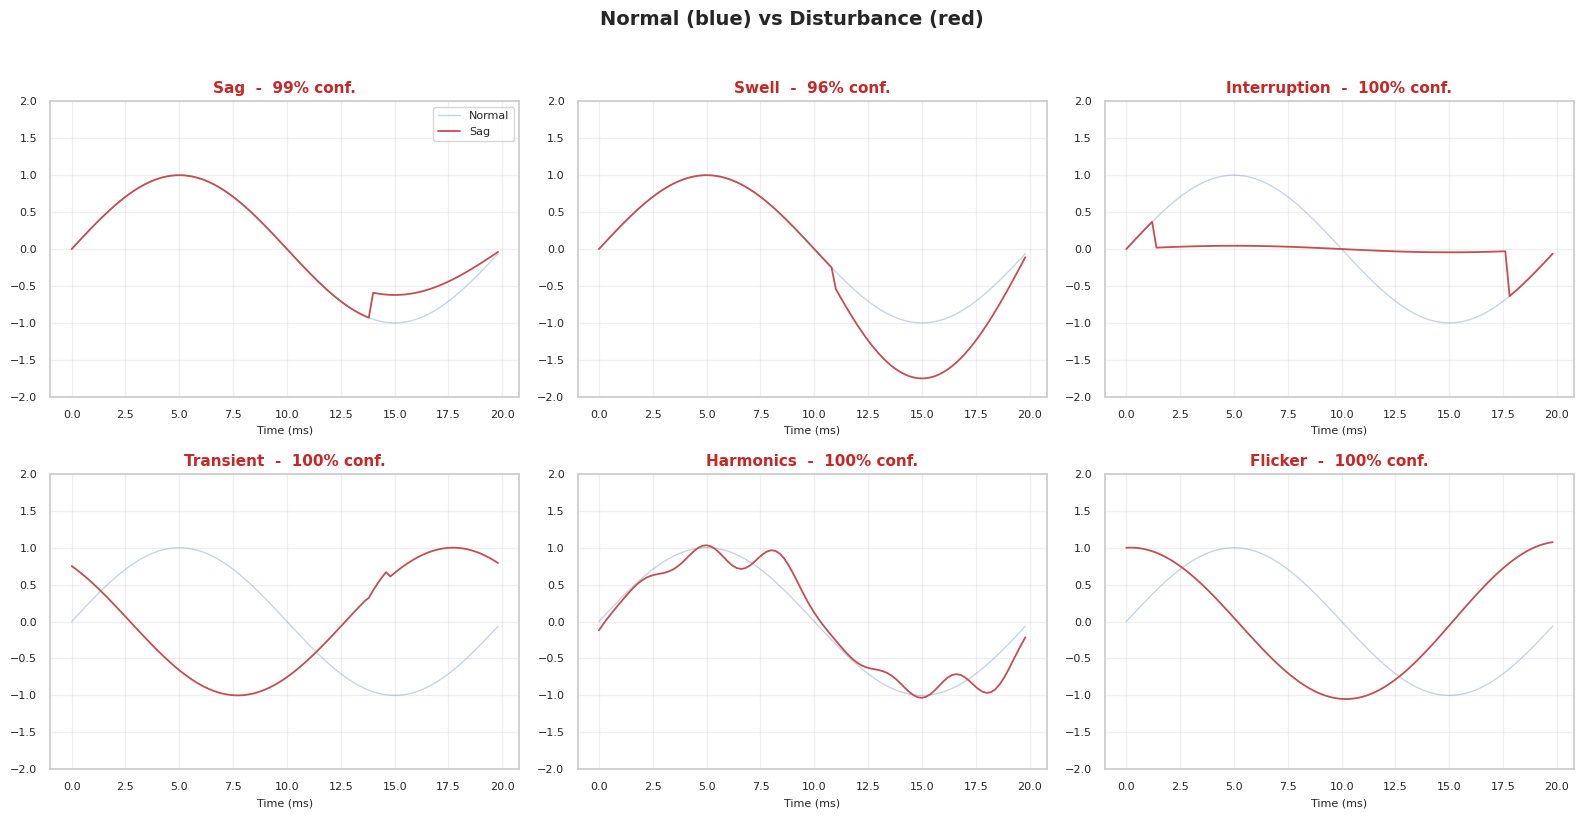

In [10]:
ref_signal = signals[labels == 'Pure_Sinusoidal'][0]

demo_classes = ['Sag', 'Swell', 'Interruption', 'Transient', 'Harmonics', 'Flicker']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, cls in enumerate(demo_classes):
    ax = axes[i]
    dist_signal = signals[labels == cls][0]
    r = predict_signal(dist_signal, model_path=DEMO_MODEL_PATH)

    ax.plot(time_ms, ref_signal, 'b-', alpha=0.3, linewidth=1, label='Normal')
    ax.plot(time_ms, dist_signal, 'r-', linewidth=1.3, label=cls)
    ax.set_title(f"{cls.replace('_', ' ')}  -  {r['confidence']:.0%} conf.",
                 fontsize=11, fontweight='bold', color='#c62828')
    ax.set_ylim(-2, 2)
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8)
fig.suptitle('Normal (blue) vs Disturbance (red)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Confidence Breakdown

Show what the model thinks — probabilities for all 17 classes.

In [11]:
def show_confidence(signal, true_label=None, model_path=DEMO_MODEL_PATH):
    """Bar chart of prediction probabilities for all classes."""
    result = predict_signal(signal, model_path=model_path)
    probs = result['all_probabilities']

    sorted_items = sorted(probs.items(), key=lambda x: x[1], reverse=True)
    names = [item[0].replace('_', ' ') for item in sorted_items]
    values = [item[1] for item in sorted_items]

    is_normal = result['status'] == 'Normal'
    colors = ['#2e7d32' if is_normal else '#c62828'] + ['#bdbdbd'] * (len(names) - 1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 2]})

    color = '#2e7d32' if is_normal else '#c62828'
    axes[0].plot(time_ms, signal, color=color, linewidth=1.3)
    axes[0].fill_between(time_ms, signal, alpha=0.1, color=color)
    axes[0].set_title('Input Signal', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Time (ms)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)

    bars = axes[1].barh(range(len(names)), values, color=colors)
    axes[1].set_yticks(range(len(names)))
    axes[1].set_yticklabels(names, fontsize=9)
    axes[1].set_xlabel('Probability', fontsize=11)
    axes[1].set_title(f"Prediction: {result['disturbance_type'].replace('_', ' ')} ({result['confidence']:.0%})",
                      fontsize=12, fontweight='bold', color=color)
    axes[1].set_xlim(0, 1.1)
    axes[1].invert_yaxis()

    for bar, val in zip(bars, values):
        if val > 0.005:
            axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                         f'{val:.0%}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

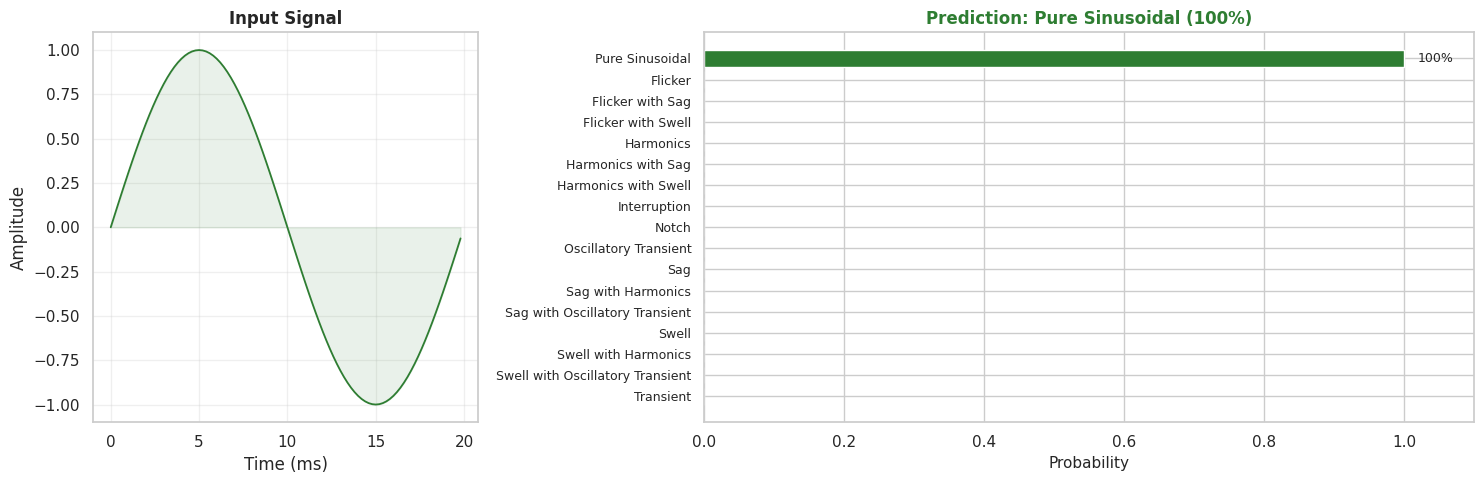

In [12]:
# Normal signal
idx = (labels == 'Pure_Sinusoidal').nonzero()[0][0]
show_confidence(signals[idx])

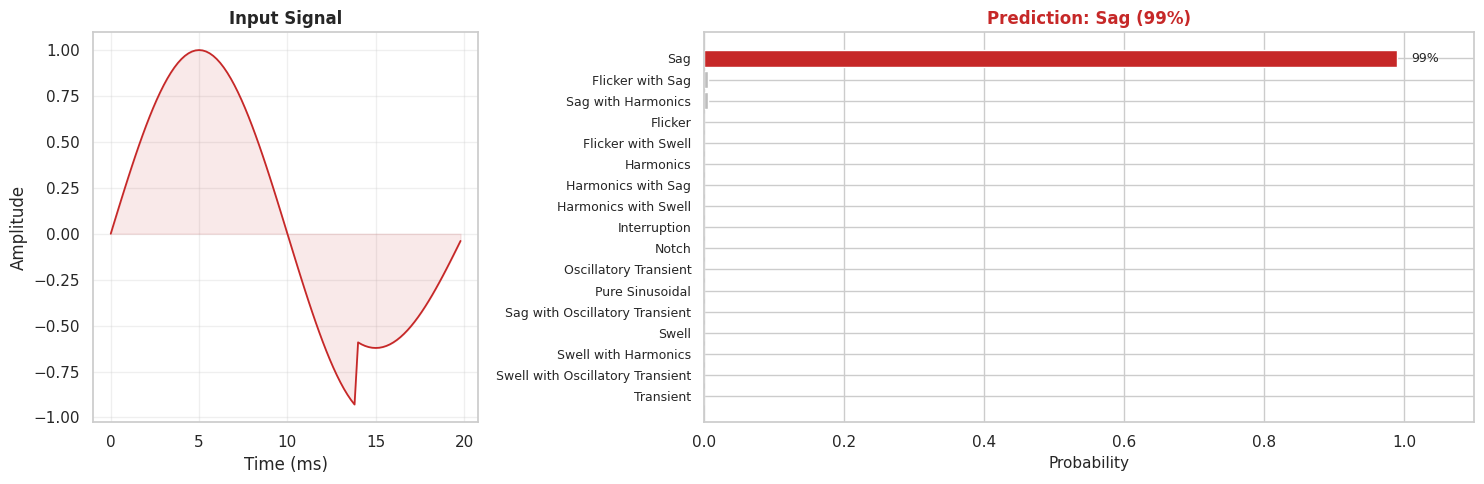

In [13]:
# Sag signal
idx = (labels == 'Sag').nonzero()[0][0]
show_confidence(signals[idx])

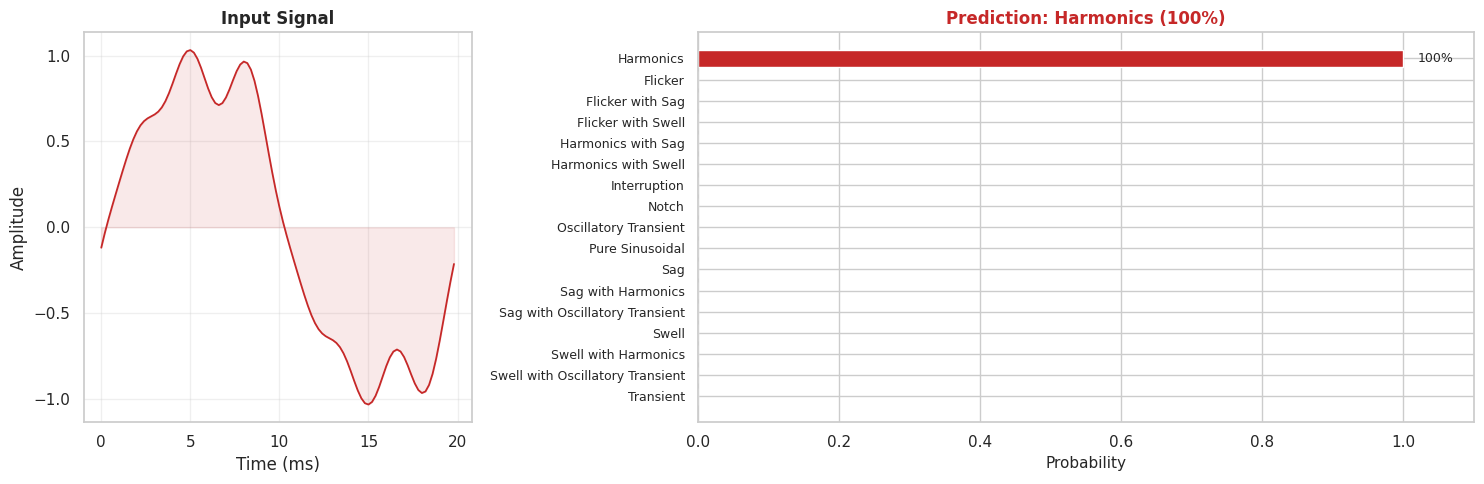

In [14]:
# Harmonics signal
idx = (labels == 'Harmonics').nonzero()[0][0]
show_confidence(signals[idx])

---
## 5. Pick Any Random Signal

Run this cell multiple times — each time it picks a random signal and predicts it.

Randomly picked signal #3309


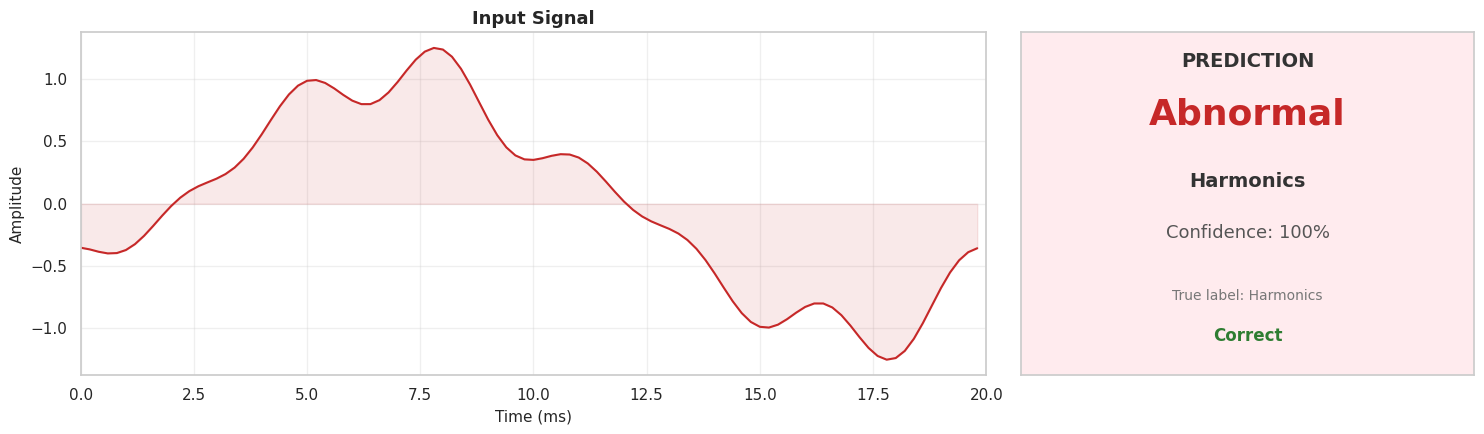

In [15]:
idx = np.random.randint(0, len(signals))
true_label = labels[idx]

print(f'Randomly picked signal #{idx}')
_ = demo_predict(signals[idx], true_label)

---
## 6. Batch Monitoring Simulation

Simulate monitoring 20 random signals — like a real-time power quality monitor.

In [16]:
np.random.seed(123)
random_indices = np.random.choice(len(signals), 20, replace=False)
batch_signals = signals[random_indices]
batch_labels = labels[random_indices]

results = predict_batch(batch_signals, model_path=DEMO_MODEL_PATH)

print(f'{"#":<4} {"True Label":<35} {"Predicted":<35} {"Status":<10} {"Conf":<8} {""}')
print('-' * 100)

normal_count = 0
abnormal_count = 0

for i, (r, true_label) in enumerate(zip(results, batch_labels)):
    status_icon = '[OK]' if r['status'] == 'Normal' else '[!!]'
    match = true_label == r['disturbance_type']
    mark = '' if match else ' <-- misclassified'

    if r['status'] == 'Normal':
        normal_count += 1
    else:
        abnormal_count += 1

    print(f"{i+1:<4} {true_label.replace('_', ' '):<35} {r['disturbance_type'].replace('_', ' '):<35} {status_icon:<10} {r['confidence']:<8.0%}{mark}")

print('-' * 100)
print(f'Summary: {normal_count} Normal, {abnormal_count} Abnormal out of 20 signals')

#    True Label                          Predicted                           Status     Conf     
----------------------------------------------------------------------------------------------------
1    Flicker                             Flicker                             [!!]       100%    
2    Swell with Harmonics                Swell with Harmonics                [!!]       55%     
3    Harmonics                           Harmonics                           [!!]       100%    
4    Sag with Oscillatory Transient      Sag with Oscillatory Transient      [!!]       67%     
5    Harmonics                           Harmonics                           [!!]       100%    
6    Flicker                             Flicker                             [!!]       100%    
7    Pure Sinusoidal                     Pure Sinusoidal                     [OK]       100%    
8    Swell with Harmonics                Swell with Harmonics                [!!]       83%     
9    Swell with Harmonics